STEP 1. 데이터 불러오기
orders 크기: (3421083, 7)
prior_products 크기: (32434489, 4)
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  

빈 값 개수:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

STEP 2. 메모리 최적화
최적화 전 메모리: 332.7 MB
최적화 후

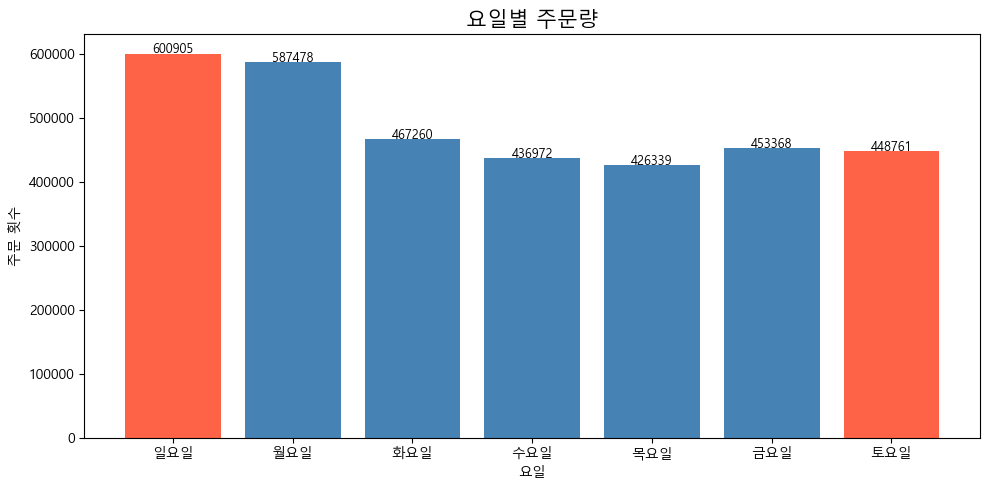

[완료] graph1_요일별주문량.png


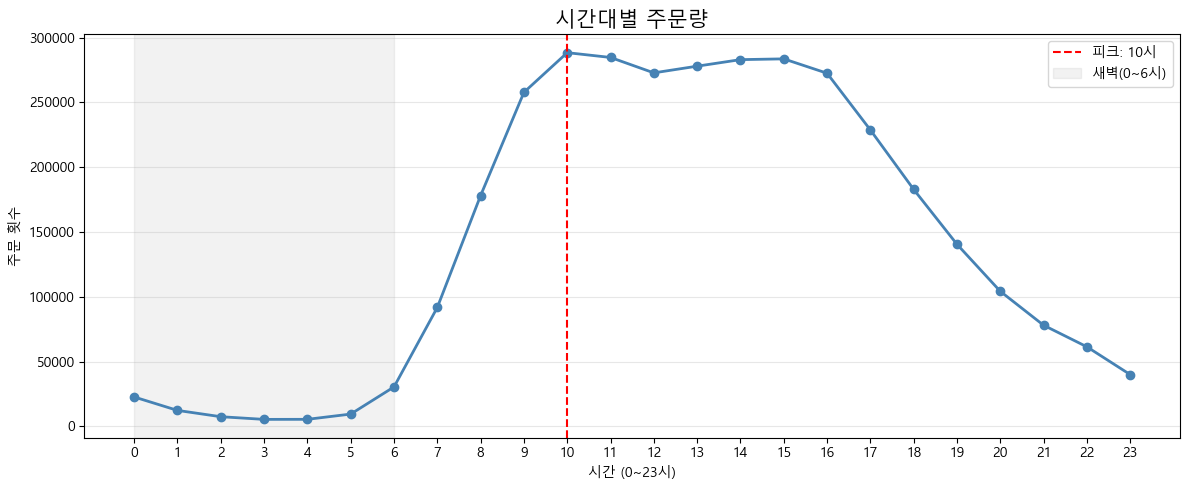

[완료] graph2_시간대별주문량.png

평균 재구매 주기: 11.100000381469727일
중앙값: 7.0일
최빈값: 30.0일


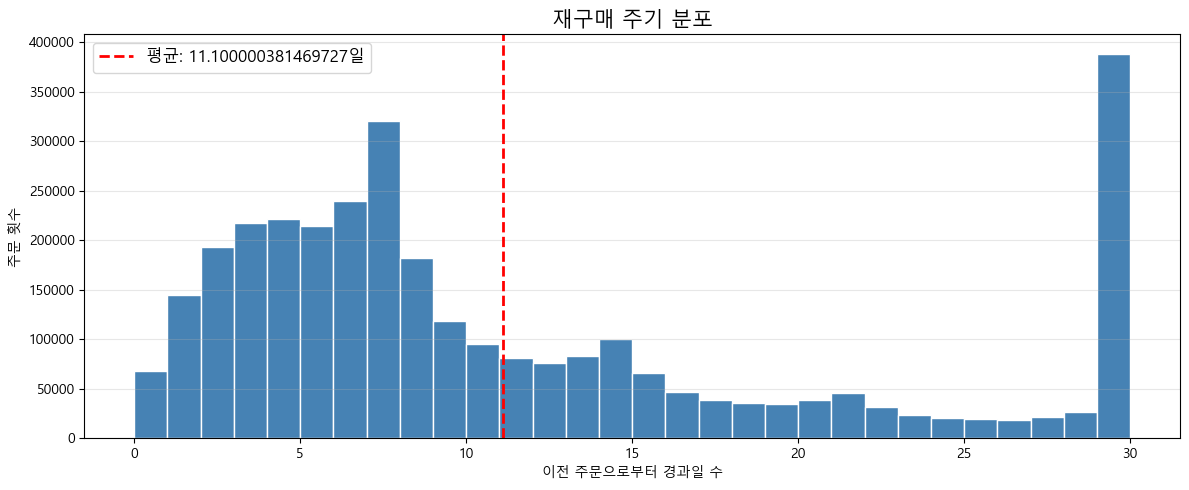

[완료] graph3_재구매주기분포.png

STEP 4. prior / train 분리
prior 주문 수: 3214874
train  주문 수: 131209
prior_merged 크기: (32434489, 5)

STEP 5. 유저 피처 생성 (13개)
유저 피처 완성: (206209, 14)
컬럼: ['user_id', 'user_total_orders', 'user_avg_days_between', 'user_std_days_between', 'user_total_items', 'user_distinct_items', 'user_reorder_ratio', 'favorite_dow', 'favorite_hour', 'user_last_dow', 'user_last_hour', 'user_dow_std', 'user_hour_std', 'user_weekend_ratio']
   user_id  user_total_orders  user_avg_days_between  user_std_days_between  \
0        1                 10              19.555555               9.395625   
1        2                 14              15.230769               9.867065   
2        3                 12              12.090909               5.375026   
3        4                  5              13.750000               9.500000   
4        5                  4              13.333333               4.932883   

   user_total_items  user_distinct_items  user_reorder_ratio  favorite_dow  \
0   

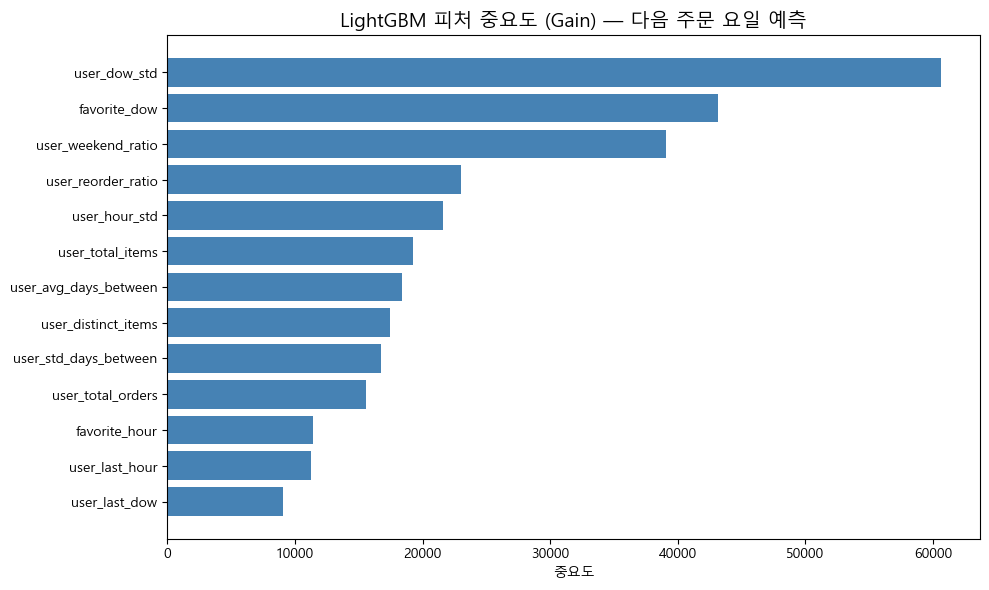

[완료] graph4_feature_importance.png

모델 저장 완료! → ../data/prep/lgbm_dow_model.txt

전체 파이프라인 완료!
저장된 파일 목록:
  - ../data/prep/user_features.csv
  - ../data/prep/final_dataset_dow.csv
  - ../data/prep/lgbm_dow_model.txt
  - graph1_요일별주문량.png
  - graph2_시간대별주문량.png
  - graph3_재구매주기분포.png
  - graph4_feature_importance.png


In [22]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 한글 폰트 설정
# =============================================
font_path = 'C:/Windows/Fonts/malgun.ttf'
font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font.get_name()
plt.rcParams['axes.unicode_minus'] = False

요일이름 = {0: '일요일', 1: '월요일', 2: '화요일', 3: '수요일',
             4: '목요일', 5: '금요일', 6: '토요일'}
요일순서 = ['일요일', '월요일', '화요일', '수요일', '목요일', '금요일', '토요일']


# =============================================
# STEP 1. 데이터 불러오기
# =============================================
print('=' * 50)
print('STEP 1. 데이터 불러오기')
print('=' * 50)

orders         = pd.read_csv('../data/raw/orders.csv')
prior_products = pd.read_csv('../data/raw/order_products__prior.csv')

print('orders 크기:', orders.shape)
print('prior_products 크기:', prior_products.shape)
print(orders.head())
print('\n빈 값 개수:')
print(orders.isnull().sum())


# =============================================
# STEP 2. 메모리 최적화
# =============================================
print('\n' + '=' * 50)
print('STEP 2. 메모리 최적화')
print('=' * 50)

before = orders.memory_usage(deep=True).sum() / 1024**2
print('최적화 전 메모리:', round(before, 1), 'MB')

orders['order_dow']              = orders['order_dow'].astype('int8')
orders['order_hour_of_day']      = orders['order_hour_of_day'].astype('int8')
orders['order_number']           = orders['order_number'].astype('int16')
orders['days_since_prior_order'] = orders['days_since_prior_order'].astype('float32')
prior_products['reordered']      = prior_products['reordered'].astype('int8')
prior_products['product_id']     = prior_products['product_id'].astype('int32')

after = orders.memory_usage(deep=True).sum() / 1024**2
print('최적화 후 메모리:', round(after, 1), 'MB')


# =============================================
# STEP 3. EDA 시각화
# =============================================
print('\n' + '=' * 50)
print('STEP 3. EDA 시각화')
print('=' * 50)

# --- 3-1. 요일별 주문량 ---
orders['요일'] = orders['order_dow'].map(요일이름)
요일별주문수   = orders['요일'].value_counts().reindex(요일순서)
색깔리스트     = ['tomato' if 요일 in ('일요일', '토요일') else 'steelblue'
                  for 요일 in 요일순서]

plt.figure(figsize=(10, 5))
plt.bar(요일순서, 요일별주문수.values, color=색깔리스트)
plt.title('요일별 주문량', fontsize=15)
plt.xlabel('요일')
plt.ylabel('주문 횟수')
for i, 숫자 in enumerate(요일별주문수.values):
    plt.text(i, 숫자 + 500, str(숫자), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('graph1_요일별주문량.png', dpi=150, bbox_inches='tight')
plt.show()
print('[완료] graph1_요일별주문량.png')

# --- 3-2. 시간대별 주문량 ---
시간대별주문수 = orders['order_hour_of_day'].value_counts().sort_index()
피크시간       = 시간대별주문수.idxmax()

plt.figure(figsize=(12, 5))
plt.plot(시간대별주문수.index, 시간대별주문수.values,
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=피크시간, color='red', linestyle='--', label=f'피크: {피크시간}시')
plt.axvspan(0, 6, alpha=0.1, color='gray', label='새벽(0~6시)')
plt.title('시간대별 주문량', fontsize=15)
plt.xlabel('시간 (0~23시)')
plt.ylabel('주문 횟수')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph2_시간대별주문량.png', dpi=150, bbox_inches='tight')
plt.show()
print('[완료] graph2_시간대별주문량.png')

# --- 3-3. 재구매 주기 분포 ---
재구매데이터 = orders['days_since_prior_order'].dropna()
평균값       = 재구매데이터.mean()
print(f'\n평균 재구매 주기: {round(평균값, 1)}일')
print(f'중앙값: {재구매데이터.median()}일')
print(f'최빈값: {재구매데이터.mode()[0]}일')

plt.figure(figsize=(12, 5))
plt.hist(재구매데이터, bins=30, color='steelblue', edgecolor='white')
plt.axvline(x=평균값, color='red', linestyle='--', linewidth=2,
            label=f'평균: {round(평균값, 1)}일')
plt.title('재구매 주기 분포', fontsize=15)
plt.xlabel('이전 주문으로부터 경과일 수')
plt.ylabel('주문 횟수')
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph3_재구매주기분포.png', dpi=150, bbox_inches='tight')
plt.show()
print('[완료] graph3_재구매주기분포.png')


# =============================================
# STEP 4. prior / train 분리
# =============================================
print('\n' + '=' * 50)
print('STEP 4. prior / train 분리')
print('=' * 50)

prior_orders = orders[orders['eval_set'] == 'prior']
train_orders = orders[orders['eval_set'] == 'train']

print('prior 주문 수:', len(prior_orders))
print('train  주문 수:', len(train_orders))

prior_merged = prior_products.merge(
    prior_orders[['order_id', 'user_id']], on='order_id'
)
print('prior_merged 크기:', prior_merged.shape)


# =============================================
# STEP 5. 유저 피처 생성 (13개)
# =============================================
print('\n' + '=' * 50)
print('STEP 5. 유저 피처 생성 (13개)')
print('=' * 50)

# Feature 1~8: 기본 피처
user_total_orders = (prior_orders.groupby('user_id')['order_number']
                                 .max().reset_index())
user_total_orders.columns = ['user_id', 'user_total_orders']

_재구매 = prior_orders[prior_orders['days_since_prior_order'].notnull()]
user_avg_days = (_재구매.groupby('user_id')['days_since_prior_order']
                        .mean().reset_index())
user_avg_days.columns = ['user_id', 'user_avg_days_between']

user_std_days = (_재구매.groupby('user_id')['days_since_prior_order']
                        .std().reset_index())
user_std_days.columns = ['user_id', 'user_std_days_between']

user_total_items = (prior_merged.groupby('user_id')['product_id']
                                .count().reset_index())
user_total_items.columns = ['user_id', 'user_total_items']

user_distinct_items = (prior_merged.groupby('user_id')['product_id']
                                   .nunique().reset_index())
user_distinct_items.columns = ['user_id', 'user_distinct_items']

user_reorder_ratio = (prior_merged.groupby('user_id')['reordered']
                                  .mean().reset_index())
user_reorder_ratio.columns = ['user_id', 'user_reorder_ratio']

favorite_dow = (prior_orders.groupby('user_id')['order_dow']
                             .agg(lambda x: x.mode()[0]).reset_index())
favorite_dow.columns = ['user_id', 'favorite_dow']

favorite_hour = (prior_orders.groupby('user_id')['order_hour_of_day']
                              .agg(lambda x: x.mode()[0]).reset_index())
favorite_hour.columns = ['user_id', 'favorite_hour']

# Feature 9~13: 추가 피처
orders_info   = orders[['order_id', 'user_id', 'order_dow', 'order_hour_of_day']]
prior_merged2 = prior_merged.merge(orders_info, on=['order_id', 'user_id'], how='left')

additional_features = prior_merged2.groupby('user_id').agg(
    user_last_dow      = ('order_dow', 'last'),
    user_last_hour     = ('order_hour_of_day', 'last'),
    user_dow_std       = ('order_dow', 'std'),
    user_hour_std      = ('order_hour_of_day', 'std'),
    user_weekend_ratio = ('order_dow', lambda x: (x.isin([0, 1])).mean()),
).reset_index()

# 전체 합치기
user_features = user_total_orders.merge(user_avg_days,       on='user_id')
user_features = user_features.merge(user_std_days,           on='user_id')
user_features = user_features.merge(user_total_items,        on='user_id')
user_features = user_features.merge(user_distinct_items,     on='user_id')
user_features = user_features.merge(user_reorder_ratio,      on='user_id')
user_features = user_features.merge(favorite_dow,            on='user_id')
user_features = user_features.merge(favorite_hour,           on='user_id')
user_features = user_features.merge(additional_features,     on='user_id')

# 메모리 최적화
user_features['user_total_orders']     = user_features['user_total_orders'].astype('int16')
user_features['user_avg_days_between'] = user_features['user_avg_days_between'].astype('float32')
user_features['user_std_days_between'] = user_features['user_std_days_between'].astype('float32')
user_features['user_total_items']      = user_features['user_total_items'].astype('int32')
user_features['user_distinct_items']   = user_features['user_distinct_items'].astype('int16')
user_features['user_reorder_ratio']    = user_features['user_reorder_ratio'].astype('float32')
user_features['favorite_dow']          = user_features['favorite_dow'].astype('int8')
user_features['favorite_hour']         = user_features['favorite_hour'].astype('int8')

print('유저 피처 완성:', user_features.shape)
print('컬럼:', list(user_features.columns))
print(user_features.head(5))

user_features.to_csv('../data/prep/user_features.csv', index=False)
print('\n저장 완료! → ../data/prep/user_features.csv')


# =============================================
# STEP 6. 최종 데이터셋 구축
# =============================================
print('\n' + '=' * 50)
print('STEP 6. 최종 데이터셋 구축')
print('=' * 50)

# 정답 레이블: train 주문의 다음 요일
labels = train_orders[['user_id', 'order_dow']].copy()
labels.columns = ['user_id', 'next_order_dow']
labels['next_order_dow'] = labels['next_order_dow'].map(요일이름)

# 유저 피처 + 레이블 합치기
df_final = user_features.merge(labels, on='user_id', how='inner')

print('최종 데이터셋 크기:', df_final.shape)
print('\nLabel(다음 주문 요일) 분포:')
print(df_final['next_order_dow'].value_counts().reindex(요일순서))
print(df_final.head(5))

df_final.to_csv('../data/prep/final_dataset_dow.csv', index=False)
print('\n저장 완료! → ../data/prep/final_dataset_dow.csv')


# =============================================
# STEP 7. LightGBM 모델 학습
# =============================================
print('\n' + '=' * 50)
print('STEP 7. LightGBM 모델 학습 (다중 분류)')
print('=' * 50)

FEATURE_COLS = [
    'user_total_orders', 'user_avg_days_between', 'user_std_days_between',
    'user_total_items', 'user_distinct_items', 'user_reorder_ratio',
    'favorite_dow', 'favorite_hour',
    'user_last_dow', 'user_last_hour',
    'user_dow_std', 'user_hour_std',
    'user_weekend_ratio'
]

X = df_final[FEATURE_COLS]
y = df_final['next_order_dow']

# 요일 이름 → 숫자 변환
dow_map = {'일요일':0, '월요일':1, '화요일':2, '수요일':3, '목요일':4, '금요일':5, '토요일':6}
if y.dtype == object:
    y = y.map(dow_map)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'학습: {X_train.shape}  |  검증: {X_val.shape}')

dow_map = {'일요일':0, '월요일':1, '화요일':2, '수요일':3, '목요일':4, '금요일':5, '토요일':6}
y_train = y_train.map(dow_map)
y_val   = y_val.map(dow_map)

# 기존 코드 (그대로 유지)
y_train = np.array(y_train, dtype=np.float32)
y_val   = np.array(y_val,   dtype=np.float32)
# numpy 변환 (NumPy 2.x 호환)
y_train = np.array(y_train, dtype=np.float32)
y_val   = np.array(y_val,   dtype=np.float32)

# 클래스 가중치 (불균형 해결)
class_counts  = Counter(y_train.astype(int))
total         = sum(class_counts.values())
class_weight  = {k: total / (7 * v) for k, v in class_counts.items()}
sample_weight = np.array([class_weight[int(l)] for l in y_train])

lgb_train = lgb.Dataset(X_train, label=y_train, weight=sample_weight)
lgb_val   = lgb.Dataset(X_val,   label=y_val,   reference=lgb_train)

params = {
    'objective':         'multiclass',
    'num_class':         7,
    'metric':            'multi_logloss',
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         7,
    'min_child_samples': 30,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'lambda_l1':         0.1,
    'lambda_l2':         0.1,
    'verbose':           -1,
    'seed':              42,
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ]
)


# =============================================
# STEP 8. 모델 평가
# =============================================
print('\n' + '=' * 50)
print('STEP 8. 모델 평가')
print('=' * 50)

y_pred_prob = model.predict(X_val)
y_pred      = y_pred_prob.argmax(axis=1)

acc = accuracy_score(y_val, y_pred)
print(f'검증 Accuracy: {acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_val, y_pred, target_names=요일순서))


# =============================================
# STEP 9. 피처 중요도 시각화
# =============================================
print('\n' + '=' * 50)
print('STEP 9. 피처 중요도 시각화')
print('=' * 50)

importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('LightGBM 피처 중요도 (Gain) — 다음 주문 요일 예측', fontsize=14)
plt.xlabel('중요도')
plt.tight_layout()
plt.savefig('graph4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('[완료] graph4_feature_importance.png')


# =============================================
# STEP 10. 모델 저장
# =============================================
model.save_model('../data/prep/lgbm_dow_model.txt')
print('\n모델 저장 완료! → ../data/prep/lgbm_dow_model.txt')

print('\n' + '=' * 50)
print('전체 파이프라인 완료!')
print('=' * 50)
print('저장된 파일 목록:')
print('  - ../data/prep/user_features.csv')
print('  - ../data/prep/final_dataset_dow.csv')
print('  - ../data/prep/lgbm_dow_model.txt')
print('  - graph1_요일별주문량.png')
print('  - graph2_시간대별주문량.png')
print('  - graph3_재구매주기분포.png')
print('  - graph4_feature_importance.png')